In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("chinook.db")

def q(sql):
    return pd.read_sql_query(sql, conn)

## Q1. Write a query to list the top 10 genres with the highest number of tracks. (Show in bar plot)

,genre,track_count
0,Rock,1297
1,Latin,579
2,Metal,374
3,Alternative & Punk,332
4,Jazz,130
5,TV Shows,93
6,Blues,81
7,Classical,74
8,Drama,64
9,R&B/Soul,61


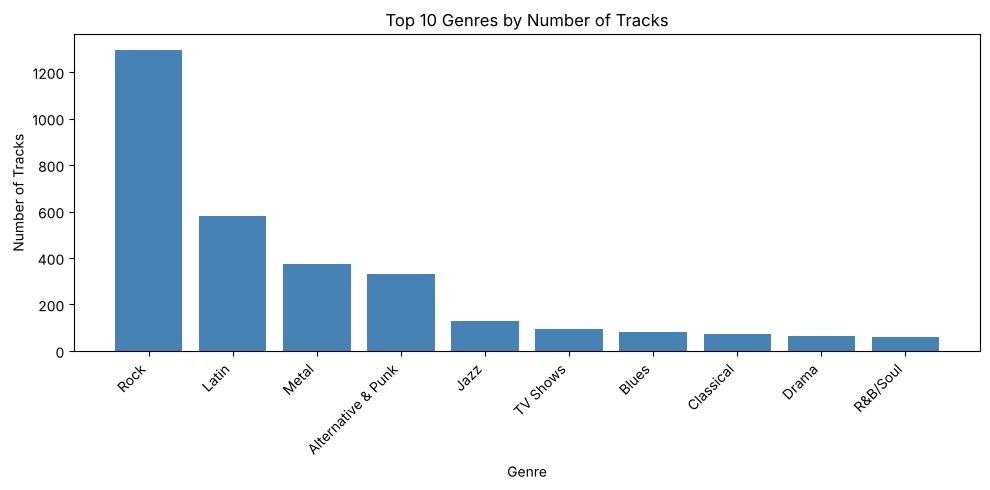

In [2]:
df1 = q("""
SELECT g.name AS genre, COUNT(t.track_id) AS track_count
FROM track t
JOIN genre g ON t.genre_id = g.genre_id
GROUP BY g.genre_id, g.name
ORDER BY track_count DESC
LIMIT 10;
""")
display(df1)

plt.figure(figsize=(10, 5))
plt.bar(df1["genre"], df1["track_count"], color="steelblue")
plt.title("Top 10 Genres by Number of Tracks")
plt.xlabel("Genre")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Q2. Write a query to list the top 10 albums that contain the most tracks.

In [3]:
q("""
SELECT al.title AS album, ar.name AS artist, COUNT(t.track_id) AS track_count
FROM album al
JOIN track t   ON al.album_id = t.album_id
JOIN artist ar ON al.artist_id = ar.artist_id
GROUP BY al.album_id, al.title, ar.name
ORDER BY track_count DESC
LIMIT 10;
""")

,album,artist,track_count
0,Greatest Hits,Lenny Kravitz,57
1,Minha Historia,Chico Buarque,34
2,Unplugged,Eric Clapton,30
3,"Lost, Season 3",Lost,26
4,"Lost, Season 1",Lost,25
5,"The Office, Season 3",The Office,25
6,My Way: The Best Of Frank Sinatra [Disc 1],Frank Sinatra,24
7,"Lost, Season 2",Lost,24
8,"Battlestar Galactica (Classic), Season 1",Battlestar Galactica (Classic),24
9,Afrociberdelia,Chico Science & Nação Zumbi,23


## Q3. Write a query to find the top 10 customers who spent the most money.

In [4]:
q("""
SELECT c.customer_id,
       c.first_name || ' ' || c.last_name AS customer_name,
       c.country,
       ROUND(SUM(i.total), 2) AS total_spent
FROM customer c
JOIN invoice i ON c.customer_id = i.customer_id
GROUP BY c.customer_id, customer_name, c.country
ORDER BY total_spent DESC
LIMIT 10;
""")

,customer_id,customer_name,country,total_spent
0,5,František Wichterlová,Czech Republic,144.54
1,6,Helena Holý,Czech Republic,128.70
2,46,Hugh O'Reilly,Ireland,114.84
3,58,Manoj Pareek,India,111.87
4,1,Luís Gonçalves,Brazil,108.90
5,13,Fernanda Ramos,Brazil,106.92
6,34,João Fernandes,Portugal,102.96
7,3,François Tremblay,Canada,99.99
8,42,Wyatt Girard,France,99.99
9,17,Jack Smith,USA,98.01


## Q4. Write a query to find the top 5 artists who generated the highest revenue from track sales.

In [5]:
q("""
SELECT ar.name AS artist,
       ROUND(SUM(il.unit_price * il.quantity), 2) AS revenue
FROM invoice_line il
JOIN track t   ON il.track_id = t.track_id
JOIN album al  ON t.album_id = al.album_id
JOIN artist ar ON al.artist_id = ar.artist_id
GROUP BY ar.artist_id, ar.name
ORDER BY revenue DESC
LIMIT 5;
""")

,artist,revenue
0,Queen,190.08
1,Jimi Hendrix,185.13
2,Nirvana,128.70
3,Red Hot Chili Peppers,128.70
4,Pearl Jam,127.71


## Q5. Countries by Average Revenue per Invoice

In [6]:
q("""
SELECT billing_country AS country,
       COUNT(invoice_id) AS invoice_count,
       ROUND(SUM(total), 2) AS total_revenue,
       ROUND(AVG(total), 2) AS avg_revenue_per_invoice
FROM invoice
GROUP BY billing_country
ORDER BY avg_revenue_per_invoice DESC;
""")

,country,invoice_count,total_revenue,avg_revenue_per_invoice
0,Czech Republic,30,273.24,9.11
1,Spain,11,98.01,8.91
2,Ireland,13,114.84,8.83
3,United Kingdom,28,245.52,8.77
4,India,21,183.15,8.72
5,Belgium,7,60.39,8.63
6,Germany,41,334.62,8.16
7,Australia,10,81.18,8.12
8,Norway,9,72.27,8.03
9,USA,131,1040.49,7.94


## Q6. Write a query to find the media type with number of tracks.


In [7]:
q("""
SELECT m.name AS media_type, COUNT(t.track_id) AS track_count
FROM media_type m
LEFT JOIN track t ON m.media_type_id = t.media_type_id
GROUP BY m.media_type_id, m.name
ORDER BY track_count DESC;
""")

,media_type,track_count
0,MPEG audio file,3034
1,Protected AAC audio file,237
2,Protected MPEG-4 video file,214
3,AAC audio file,11
4,Purchased AAC audio file,7


## Q7. Which artists have released tracks in more than one genre?

In [8]:
q("""
SELECT ar.name AS artist,
       COUNT(DISTINCT t.genre_id) AS genre_count,
       GROUP_CONCAT(DISTINCT g.name) AS genres
FROM artist ar
JOIN album al ON ar.artist_id = al.artist_id
JOIN track t  ON al.album_id = t.album_id
JOIN genre g  ON t.genre_id = g.genre_id
GROUP BY ar.artist_id, ar.name
HAVING COUNT(DISTINCT t.genre_id) > 1
ORDER BY genre_count DESC, artist;
""")

,artist,genre_count,genres
0,Iron Maiden,4,"Rock,Metal,Heavy Metal,Blues"
1,Audioslave,3,"Rock,Alternative & Punk,Alternative"
2,Battlestar Galactica,3,"Science Fiction,TV Shows,Sci Fi & Fantasy"
3,Gilberto Gil,3,"Soundtrack,Latin,Jazz"
4,Jamiroquai,3,"Rock,R&B/Soul,Electronica/Dance"
5,Lenny Kravitz,3,"Rock,Reggae,Metal"
6,Various Artists,3,"Pop,Soundtrack,Latin"
7,Amy Winehouse,2,"R&B/Soul,Pop"
8,Antônio Carlos Jobim,2,"Jazz,Latin"
9,Eric Clapton,2,"Blues,Latin"


## Q8. Write a query to list the top 10 longest tracks by duration.

In [9]:
q("""
SELECT t.name AS track, al.title AS album, ar.name AS artist,
       t.milliseconds,
       ROUND(t.milliseconds / 60000.0, 2) AS minutes
FROM track t
JOIN album al  ON t.album_id = al.album_id
JOIN artist ar ON al.artist_id = ar.artist_id
ORDER BY t.milliseconds DESC
LIMIT 10;
""")

,track,album,artist,milliseconds,minutes
0,Occupation / Precipice,"Battlestar Galactica, Season 3",Battlestar Galactica,5286953,88.12
1,Through a Looking Glass,"Lost, Season 3",Lost,5088838,84.81
2,"Greetings from Earth, Pt. 1","Battlestar Galactica (Classic), Season 1",Battlestar Galactica (Classic),2960293,49.34
3,The Man With Nine Lives,"Battlestar Galactica (Classic), Season 1",Battlestar Galactica (Classic),2956998,49.28
4,"Battlestar Galactica, Pt. 2","Battlestar Galactica (Classic), Season 1",Battlestar Galactica (Classic),2956081,49.27
5,"Battlestar Galactica, Pt. 1","Battlestar Galactica (Classic), Season 1",Battlestar Galactica (Classic),2952702,49.21
6,Murder On the Rising Star,"Battlestar Galactica (Classic), Season 1",Battlestar Galactica (Classic),2935894,48.93
7,"Battlestar Galactica, Pt. 3","Battlestar Galactica (Classic), Season 1",Battlestar Galactica (Classic),2927802,48.80
8,Take the Celestra,"Battlestar Galactica (Classic), Season 1",Battlestar Galactica (Classic),2927677,48.79
9,Fire In Space,"Battlestar Galactica (Classic), Season 1",Battlestar Galactica (Classic),2926593,48.78


## Q9. Top 5 Revenue Share percentage by Artist (Pie Chart)

,artist,revenue,revenue_share_pct
0,Queen,190.08,4.04
1,Jimi Hendrix,185.13,3.93
2,Nirvana,128.70,2.73
3,Red Hot Chili Peppers,128.70,2.73
4,Pearl Jam,127.71,2.71


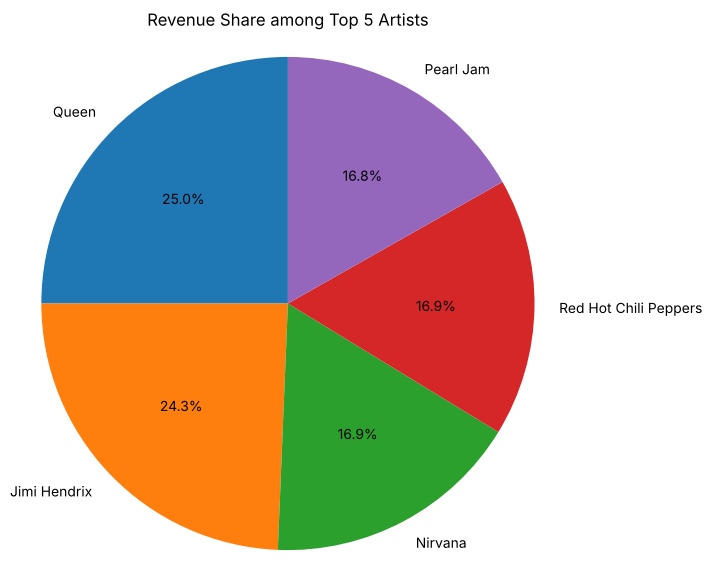

In [10]:
df9 = q("""
WITH artist_rev AS (
    SELECT ar.name AS artist, SUM(il.unit_price * il.quantity) AS revenue
    FROM invoice_line il
    JOIN track t   ON il.track_id = t.track_id
    JOIN album al  ON t.album_id = al.album_id
    JOIN artist ar ON al.artist_id = ar.artist_id
    GROUP BY ar.artist_id, ar.name
)
SELECT artist,
       ROUND(revenue, 2) AS revenue,
       ROUND(100.0 * revenue / (SELECT SUM(revenue) FROM artist_rev), 2) AS revenue_share_pct
FROM artist_rev
ORDER BY revenue DESC
LIMIT 5;
""")
display(df9)

plt.figure(figsize=(7, 7))
plt.pie(df9["revenue"], labels=df9["artist"], autopct="%1.1f%%", startangle=90)
plt.title("Revenue Share among Top 5 Artists")
plt.axis("equal")
plt.show()

## Q10. Revenue by Genre (Rock, Latin, Metal) in Each Country (Stacked Column Chart)

genre,Rock,Latin,Metal
country,,,
USA,555.39,21.78,122.76
Canada,329.67,12.87,71.28
France,208.89,26.73,53.46
Brazil,202.95,12.87,72.27
Germany,192.06,7.92,43.56
United Kingdom,164.34,6.93,30.69
Czech Republic,141.57,20.79,22.77
Portugal,106.92,5.94,27.72
India,100.98,5.94,21.78


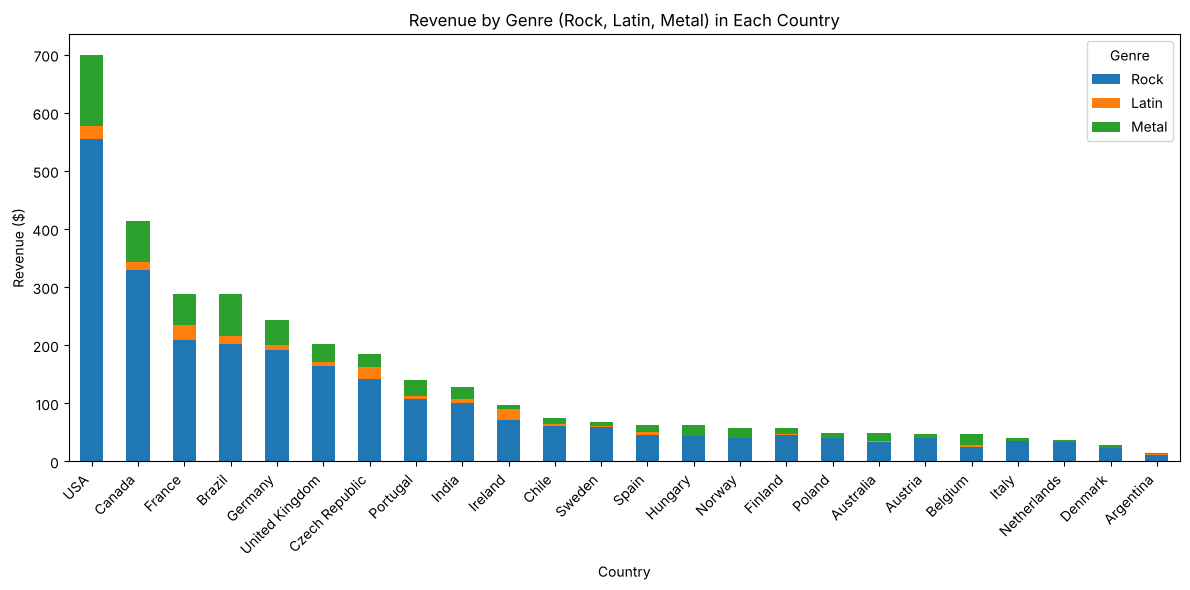

In [11]:
df10 = q("""
SELECT i.billing_country AS country,
       g.name AS genre,
       ROUND(SUM(il.unit_price * il.quantity), 2) AS revenue
FROM invoice_line il
JOIN invoice i ON il.invoice_id = i.invoice_id
JOIN track t   ON il.track_id = t.track_id
JOIN genre g   ON t.genre_id = g.genre_id
WHERE g.name IN ('Rock', 'Latin', 'Metal')
GROUP BY i.billing_country, g.name
ORDER BY country;
""")

pivot = df10.pivot(index="country", columns="genre", values="revenue").fillna(0)
pivot = pivot[["Rock", "Latin", "Metal"]]
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
display(pivot)

pivot.plot(kind="bar", stacked=True, figsize=(12, 6), color=["#1f77b4", "#ff7f0e", "#2ca02c"])
plt.title("Revenue by Genre (Rock, Latin, Metal) in Each Country")
plt.xlabel("Country")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Genre")
plt.tight_layout()
plt.show()